In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy import optimize
from scipy.interpolate import interp1d
from scipy.special import gamma

from tqdm import tqdm

from gao_sols import *

plt.style.use('science')

In [3]:
ell = 0
roots = np.loadtxt(f'datfiles/roots{ell}.dat', dtype=np.complex128)
Deltas = roots[:, 0].real
nus = roots[:, 1]

deltac = np.array([9.654418e-2, 1.473792e-1, 4.306921e-1, 1.580826, 2.073296])

In [4]:
FACTOR = 12.11928 #  K.Å^2
MASS = 1.0/FACTOR # 1/(K•Å^2)

# From the LM2M2 potential...
BETA6 = 5.54125 # increased over LM2M2 value
C6 = BETA6**4/MASS
energies = energy(Deltas, C6)

Ca = 2*np.pi/gamma(0.25)**2
Cr = gamma(0.25)**2/(3*np.pi)

def calculate_K0(a):
    return 1/(1-a/(BETA6*Ca))

In [5]:
f_nu_real = interp1d(energies, nus.real, kind='cubic')
f_nu_imag = interp1d(energies, nus.imag, kind='cubic')

In [6]:
# Deltasp = np.linspace(0.01, 10, 50)
# energiesp = energy(Deltasp, C6)
# nusp = np.array([f_nu_real(en) + f_nu_imag(en)*1j for en in energiesp])

# ii = np.where(Deltasp < deltac[ell])[0]
# jj = np.where(Deltasp > deltac[ell])[0]

# nusp[ii] = nusp[ii].real
# nusp[jj] = nusp[jj].imag*1j

In [7]:
ii = np.where(roots[:, 0].real < 10)[0]
Deltasp = roots[ii, 0].real
energiesp = energy(Deltasp, C6)
nusp = roots[ii, 1]

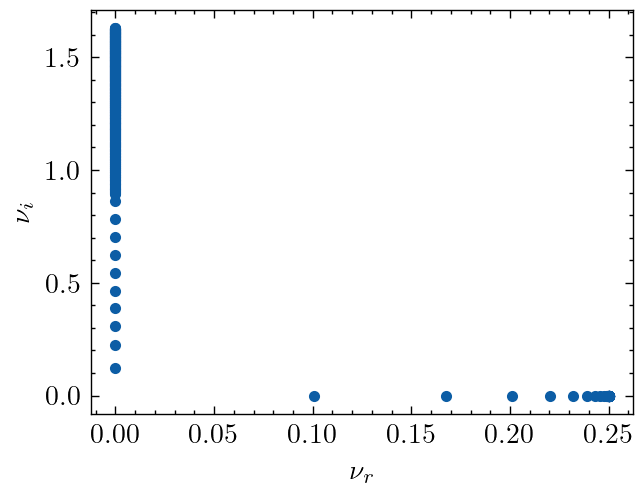

In [8]:
fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.scatter(nusp.real, nusp.imag, marker='.')

# ax.set_xlim([0.7, 1.3])
# ax.set_ylim([-0.1, 0.8])
ax.set_xlabel(r'$\nu_r$')
ax.set_ylabel(r'$\nu_i$');

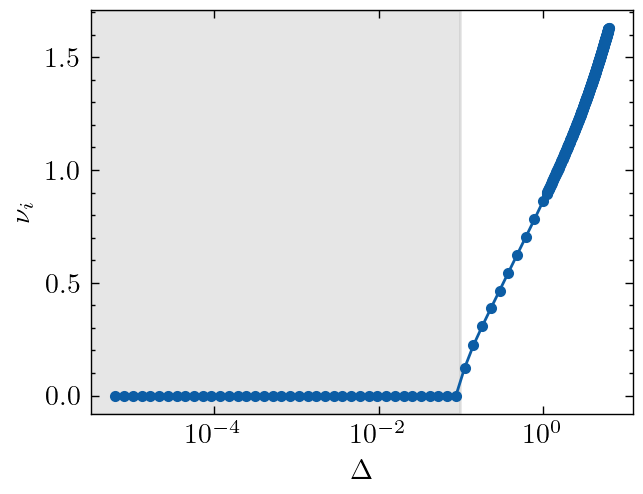

In [9]:
fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.plot(Deltasp, nusp.imag, marker='.')
ax.axvspan(0, deltac[ell], color='C6', alpha=0.25)
ax.set_xscale('log')
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$\nu_i$');

In [10]:
Zffs = np.array([Zff(en, ell, nu, C6) for (en, nu) in zip(energiesp, nusp)])
Zfgs = np.array([Zfg(en, ell, nu, C6) for (en, nu) in zip(energiesp, nusp)])
Zgfs = np.array([Zgf(en, ell, nu, C6) for (en, nu) in zip(energiesp, nusp)])
Zggs = np.array([Zgg(en, ell, nu, C6) for (en, nu) in zip(energiesp, nusp)])

In [10]:
def Z_prefactor(eps, c6, l, n):
    return 1 / ((X(eps, c6, l, n)**2 + Y(eps, c6, l, n)**2)*np.sin(np.pi*n))


def square_brackets(eps, c6, l, n):
    return alpha(eps, c6, l, n)*np.sin(np.pi*n) - beta(eps, c6, l, n)*np.cos(np.pi*n)


def bracket_left(eps, c6, l, n):
    return (-1)**(l+1) * square_brackets(eps, c6, l, n) * \
        G(-n, l, Delta(eps, c6)) * np.cos(np.pi*n - l*np.pi/2 - np.pi/4)


def bracket_right(eps, c6, l, n):
    return beta(eps, c6, l, n) * G(n, l, Delta(eps, c6)) * \
        np.sin(np.pi*n - l*np.pi/2 - np.pi/4)


def func(eps, c6, l, n):
    return Z_prefactor(eps, c6, l, n) * (bracket_left(eps, c6, l, n) + bracket_right(eps, c6, l, n))

In [11]:
y = np.array([func(en, C6, ell, nu) for (en, nu) in zip(energiesp, nusp)])

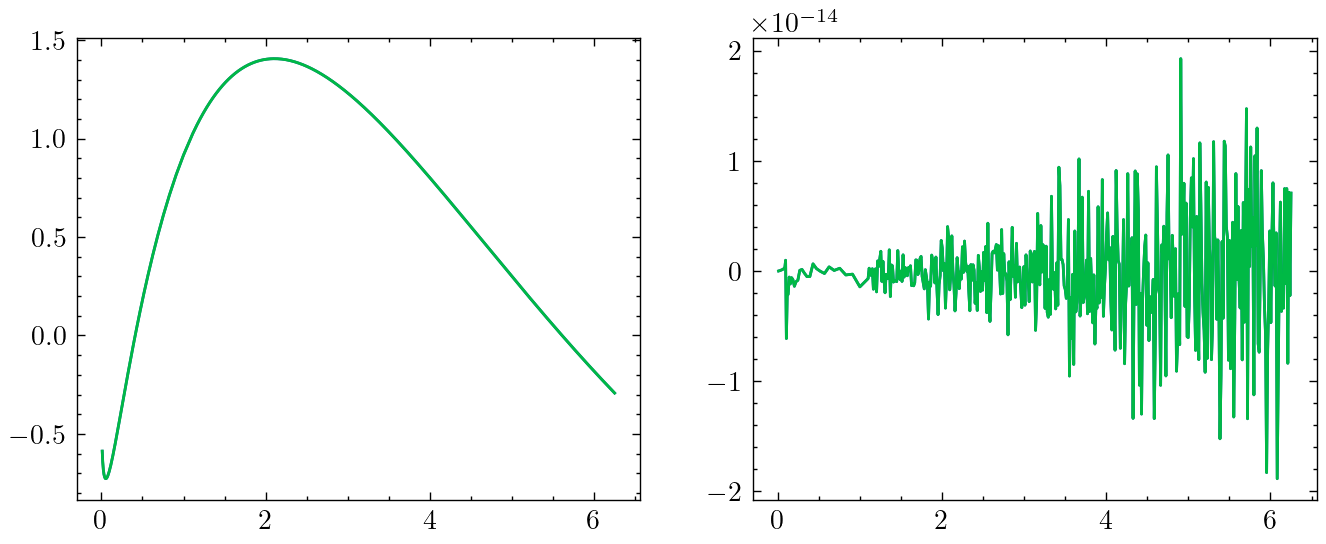

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), dpi=200)
fig.patch.set_facecolor('white')

ax[0].plot(Deltasp, y.real)
ax[1].plot(Deltasp, y.imag)
ax[0].plot(Deltasp, Zfgs.real)
ax[1].plot(Deltasp, Zfgs.imag);

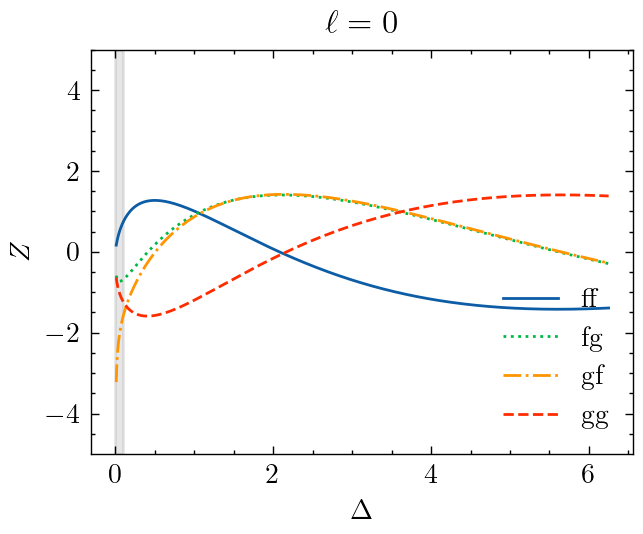

In [13]:
fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.plot(Deltasp, Zffs.real, linestyle='-', label='ff')
ax.plot(Deltasp, Zfgs.real, linestyle='dotted', label='fg')
ax.plot(Deltasp, Zgfs.real, linestyle='-.', label='gf')
ax.plot(Deltasp, Zggs.real, linestyle='dashed', label='gg')

# ax.set_xscale('log')
# ax.set_xlim([0, 10])
ax.legend(loc='lower right')
ax.set_ylim([-5, 5])
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$Z$')
ax.axvspan(0, deltac[ell], color='C6', alpha=0.25)
ax.set_title(r'$\ell=%d$' % (ell));

In [14]:
K00 = calculate_K0(100)
tandelta = (K00*Zggs - Zfgs) / (Zffs - K00*Zgfs)

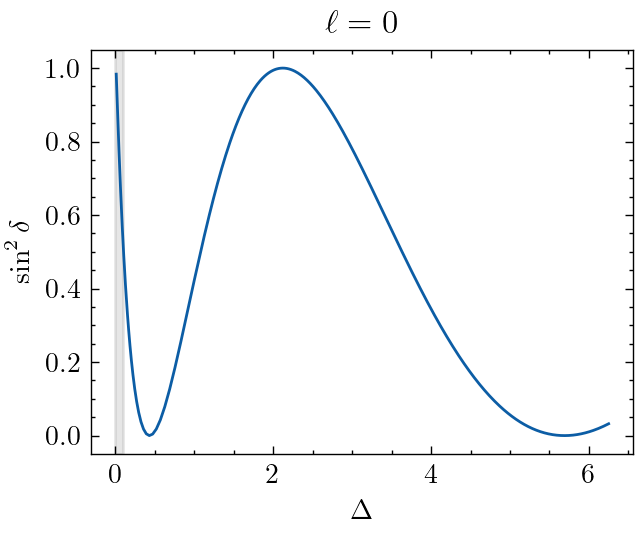

In [21]:
fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.plot(Deltasp, np.sin(np.arctan(tandelta).real)**2)

# ax.set_xscale('log')
# ax.set_xlim([0, 10])
# ax.legend(loc='lower right')
# ax.set_ylim([-5, 5])
ax.set_ylabel(r'$\sin^2\delta$')
ax.set_xlabel(r'$\Delta$')
ax.axvspan(0, deltac[ell], color='C6', alpha=0.25)
ax.set_title(r'$\ell=%d$' % (ell));